Imports and environment

In [18]:
# Install Python 3.10 or newer and run in your terminal:
# pip install "matplotlib>=3.0.0" "python-dateutil>=2.8.0" "python-dotenv>=0.21.0" "numpy==1.26.4" "opencv-python==4.11.0.86" "pandas==2.3.3" "pdf2image==1.17.0" "pillow==10.4.0" "PyMuPDF==1.26.7" "pytesseract>=0.3.10" "requests==2.32.5" "postal>=1.1.11" "geopy>=2.4.1"
# pip install ipykernel

# If using the LLMWhisperer option for new files, set up `LLMWHISPERER_API_KEY` in your environment. (Get free key online)

# If using tesseract, also need to install tesseract
# brew install tesseract (mac)
# sudo apt install tesseract-ocr libtesseract-dev tesseract-ocr-eng (linux)
# use windows installer from official repository

# if using Google geocoding API, set up `GOOGLE_API_KEY` in environment

In [19]:
import os
import json
import re
import cv2
import requests
import time
import csv
import calendar
import glob
import io
from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np
import pymupdf as fitz
import pytesseract
from pytesseract import Output
from PIL import Image
from pdf2image import convert_from_path
from dotenv import load_dotenv
from dateutil import parser as date_parser
from postal.expand import expand_address
from postal.parser import parse_address
from geopy.geocoders import ArcGIS, GoogleV3
from geopy.extra.rate_limiter import RateLimiter
import matplotlib.pyplot as plt

load_dotenv()

True

Constants, regex patterns, and DataFrame loading

In [20]:
DATA_ROOT = Path("data")

PARAMETERS_DF = pd.read_csv("data/parameters.csv")

COUNTIES = ["fresno_madera", "kern", "kings", "tulare_west", "tulare_east", "rancho_cordova"]

LLMWHISPERER_API_KEY = os.getenv("LLMWHISPERER_API_KEY", "")
LLMWHISPERER_BASE_URL = "https://llmwhisperer-api.us-central.unstract.com/api/v2"

PAGE_RE = re.compile(r"=== Page (\d+) ===")

YEAR, REGION = "2024", "R5"

LOCATIONS_DF = pd.read_csv(os.path.join("data", "parameter_locations.csv"))
TEMPLATES_DF = pd.read_csv(os.path.join("data", "templates.csv"))

param_dicts_df = PARAMETERS_DF[PARAMETERS_DF["manifest_type"].isin(["manure", "wastewater", "both"])]
param_dicts = {
    "key_to_name": dict(zip(param_dicts_df["parameter_key"], param_dicts_df["parameter_name"])),
    "key_to_type": dict(zip(param_dicts_df["parameter_key"], param_dicts_df["data_type"])),
    "key_to_default": dict(zip(param_dicts_df["parameter_key"], param_dicts_df["default"])),
}
params = param_dicts["key_to_name"]


PARAM_TO_COL = param_dicts["key_to_name"]
PARAM_TYPES = param_dicts["key_to_type"]

# Regex patterns for load extraction
NUM = r"(\d+(?:\.\d+)?)"
LOAD = (
    "(?:"
    + "|".join(
        f"{t}s?"
        for t in ["load", "loap", "haul", "truckload", "dump\\s*t(?:k|ruck)", "tanker\\s*load"]
    )
    + ")"
)
UNIT = "(" + "|".join(f"{t}s?" for t in ["ton", "gallon", "gal", "yard"]) + ")"
SEP = r"\s*(?:[x×@\-]|at)\s*"
APPROX = r"(?:approx\.?\s*)?"

LOAD_PATTERNS = [
    (re.compile(rf"{NUM}\s*{LOAD}(?:\s+\w+)*?{SEP}{APPROX}{NUM}\s*{UNIT}", re.I), (0, 1, 2)),
    (re.compile(rf"{NUM}\s*{UNIT}{SEP}{NUM}\s*{LOAD}", re.I), (2, 0, 1)),
    (re.compile(rf"{NUM}\s*{LOAD}\s+{NUM}\s*{UNIT}\s+each\b", re.I), (0, 1, 2)),
]

HOURS_RE = re.compile(r"(\d+(?:\s*\d+/\d+)?(?:\.\d+)?)\s*(?:hours?|hrs?)\b", re.I)
GPM_RE = re.compile(r"(\d+(?:,\d+)?(?:\.\d+)?)\s*(?:gpm|gallons per min)\b", re.I)
FRAC_RE = re.compile(r"(\d+)(\d)/(\d+)")
TABLE_ROW_RE = re.compile(r"^(.+?)\s+([\d,]+)\s+(tons?|gallons?|gals?|yards?)\s+(\d+)\s*%", re.I)
PHONE_RE = re.compile(r"\(?\d{3}\)?[\s\-\.]?\d{3,4}[\s\-\.]?\d{4}")

MONTHS = "|".join(calendar.month_name[1:] + calendar.month_abbr[1:]).lower()
DATE_TOKEN_RE = re.compile(
    rf"\d{{1,2}}/\d{{1,2}}/\d{{2,4}}|(?:{MONTHS})(?:\s+\d{{1,2}})?(?:\s*,?\s*\d{{2,4}})?", re.I
)
MONTH_ONLY_RE = re.compile(rf"^\s*({MONTHS})\s*$", re.I)
YEAR_RE = re.compile(r"\b(19|20)\d{2}\b")
YEAR_ONLY_RE = re.compile(r"^202\d$")
DAY_RE = re.compile(r"(?<!\d)\d{1,2}(?!\d)")

PARCEL_RE = re.compile(
    r"(?:\(?\d*\)?\s*[Xx]?\s*)?([\dXx]{2,}\s*[.\-]\s*[\dXx]{2,}(?:\s*[.\-]\s*[\dXx]+)*)",
    re.IGNORECASE,
)

KEEP_UPPER = {"LLC", "GPM", "INC", "CA", "DBA", "NA", "N/A"}

# Load common errors from CSV
common_errors_path = os.path.join("data", "common_errors.csv")
df_errors = pd.read_csv(common_errors_path)
df_errors = df_errors.dropna(subset=["error", "correct"])
CI_ERRORS = {row["error"]: row["correct"] for _, row in df_errors[df_errors["cs"] == False].iterrows()}
CS_ERRORS = {row["error"]: row["correct"] for _, row in df_errors[df_errors["cs"] == True].iterrows()}
STRIP_CHARS = ["|", ",", "=", ":", "___"]

Helper functions

In [ ]:
def coerce_columns(df):
    """Coerce columns to their data_type from parameters.csv (in-place)."""
    for dtype, names in PARAMETERS_DF.groupby("data_type")["parameter_name"].apply(set).items():
        cols = [c for c in df.columns if c in names]
        if not cols:
            continue
        if dtype == "numeric":
            df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
        elif dtype == "date":
            for c in cols:
                df[c] = pd.to_datetime(df[c], format="mixed", dayfirst=False, errors="coerce")
        elif dtype == "boolean":
            for c in cols:
                df[c] = (
                    df[c]
                    .astype(str)
                    .str.strip()
                    .str.upper()
                    .map({"TRUE": True, "FALSE": False, "NAN": None})
                )
    return df


def get_files_by_template(output_path, detect_pages=False):
    """Returns a list of dicts with county, template, filename, manifest_count, manifest_pages, detected_pages."""
    existing_detected = {}
    existing_manifest = {}
    if Path(output_path).exists():
        with open(output_path, newline="") as f:
            for row in csv.DictReader(f):
                fname = row["filename"]
                if not detect_pages and row.get("detected_pages"):
                    existing_detected[fname] = row["detected_pages"]
                if row.get("manifest_count") or row.get("manifest_pages"):
                    existing_manifest[fname] = {
                        "manifest_count": row.get("manifest_count", ""),
                        "manifest_pages": row.get("manifest_pages", ""),
                    }

    files_list = []
    for county in COUNTIES:
        county_dir = DATA_ROOT / REGION / county
        for template_dir in county_dir.iterdir():
            if template_dir.name.startswith(".") or template_dir.name == "all_manifests" or not template_dir.is_dir():
                continue

            for pdf_file in (template_dir / "original").iterdir():
                if pdf_file.suffix.lower() != ".pdf":
                    continue

                manifest_count = 0
                start_pages = []
                for ocr_method in ["llmwhisperer", "tesseract"]:
                    txt_file = template_dir / f"{ocr_method}_output" / f"{pdf_file.stem}.txt"
                    if not txt_file.exists():
                        continue
                    raw_text = txt_file.read_text(encoding="utf-8", errors="ignore")
                    if raw_text.strip() == "no_manifests_found":
                        break
                    all_manifests_dir = DATA_ROOT / REGION / county / "all_manifests" / pdf_file.stem
                    manifest_count = len(list(all_manifests_dir.glob("manifest_*.txt"))) if all_manifests_dir.exists() else 0
                    for _, (start, end), _ in identify_manifest_pages(raw_text):
                        start_pages.extend(range(start, end + 1))
                    break

                detected_str = existing_detected.get(pdf_file.name, "")
                if detect_pages:
                    detected = detect_manifest_pages_in_pdf(str(template_dir / "original" / pdf_file.name))
                    detected_str = ",".join(str(p) for p in detected)
                    print(f"  [{len(files_list) + 1}] {pdf_file.name} page #s {detected_str}")
                
                existing = existing_manifest.get(pdf_file.name, {})
                detected_str = existing_detected.get(pdf_file.name, "")
                files_list.append({
                    "county": county,
                    "template": template_dir.name,
                    "filename": pdf_file.name,
                    "manifest_count": existing.get("manifest_count") or manifest_count,
                    "manifest_pages": existing.get("manifest_pages") or ",".join(str(p) for p in sorted(set(start_pages))),
                    "detected_pages": detected_str,
                })

    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(
            f, fieldnames=["county", "template", "filename", "manifest_count", "manifest_pages", "detected_pages"]
        )
        writer.writeheader()
        writer.writerows(files_list)

    return files_list


def deskew_image_with_tesseract_osd(image_bgr):
    """Use Tesseract OSD to deskew/rotate page image."""
    try:
        osd = pytesseract.image_to_osd(
            cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), output_type=Output.DICT
        )
        angle = float(osd.get("rotate", 0))
        if not angle:
            return image_bgr
        h, w = image_bgr.shape[:2]
        cx, cy = w / 2.0, h / 2.0
        mat = cv2.getRotationMatrix2D((cx, cy), -angle, 1.0)
        cos, sin = abs(mat[0, 0]), abs(mat[0, 1])
        new_w, new_h = int(h * sin + w * cos), int(h * cos + w * sin)
        mat[0, 2] += new_w / 2.0 - cx
        mat[1, 2] += new_h / 2.0 - cy
        return cv2.warpAffine(image_bgr, mat, (new_w, new_h))
    except pytesseract.TesseractError:
        return image_bgr

def detect_manifest_pages_in_pdf(pdf_path, *, detect_orientation=False):
    """Find pages containing manifest-specific terms."""
    manifest_pages = []
    with fitz.open(pdf_path) as doc:
        page_count = len(doc)
        first_attachment_page = next(
            (i for i in range(page_count) if "required attachments" in doc[i].get_text().lower()),
            0,
        )
        for page_num in range(first_attachment_page, page_count):
            page = doc[page_num]
            text = page.get_text().lower()
            if len(text.strip()) < 50:
                pix = page.get_pixmap(dpi=120)
                pil_img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
                img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                img_bgr = img_bgr[: img_bgr.shape[0] // 3 * 2]
                if detect_orientation:
                    img_bgr = deskew_image_with_tesseract_osd(img_bgr)
                text = pytesseract.image_to_string(
                    cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), config="--psm 6 --oem 1"
                ).lower()
            if any(term in text for term in [
                "hauler info", "destination", "method used", "operator shall",
                "d-2", "solids content", "hauler signature", "hauling event", "complete one",
            ]):
                manifest_pages.extend([page_num + 1, page_num + 2])
    return sorted(set(p for p in manifest_pages if p <= page_count))

def extract_pdf_text_by_method(pdf_path, method="fitz", pages_to_process=None):
    """Extract text from PDF using specified method."""
    if pages_to_process is None:
        with fitz.open(pdf_path) as doc:
            pages_to_process = list(range(1, len(doc) + 1))

    if method == "fitz":
        all_text = []
        with fitz.open(pdf_path) as doc:
            for p in pages_to_process:
                text = doc[p - 1].get_text()
                if text.strip():
                    all_text.append(f"=== Page {p} ===\n{text}")
        return {"result_text": "\n\n".join(all_text), "extraction_method": "fitz"}

    if method == "tesseract":
        all_text = []
        all_confs = []
        for page_num in pages_to_process:
            last_error = None
            for dpi in (350, 250, 200, 150):
                try:
                    images = convert_from_path(pdf_path, dpi=dpi, first_page=page_num, last_page=page_num)
                    break
                except Image.DecompressionBombError as e:
                    last_error = e
            else:
                raise last_error
            img = cv2.cvtColor(np.array(images[0]), cv2.COLOR_RGB2BGR)
            img = deskew_image_with_tesseract_osd(img)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
            _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            config = "--oem 1 --psm 4 -c preserve_interword_spaces=1"
            text = pytesseract.image_to_string(thresh, config=config)
            conf_data = pytesseract.image_to_data(thresh, config=config, output_type=Output.DICT)
            all_confs.extend(c for c in conf_data["conf"] if c != -1)
            all_text.append(f"=== Page {page_num} ===\n{text}")
        mean_confidence = sum(all_confs) / len(all_confs) if all_confs else 0
        return {"result_text": "\n\n".join(all_text), "extraction_method": "tesseract", "mean_confidence": mean_confidence}

    if method == "llmwhisperer":
        return extract_pdf_text_llmwhisperer_api(pdf_path, pages_to_process=pages_to_process)

def extract_pdf_text_llmwhisperer_api(pdf_path, pages_to_process=None, max_pages=999, *, keep_raw=False):
    """Extract text using LLMWhisperer API."""
    if not LLMWHISPERER_API_KEY:
        raise ValueError("LLMWHISPERER_API_KEY not set")

    sep = "<<<PAGE_BREAK>>>"
    params = {
        "mode": "form",
        "timeout": 300,
        "output_mode": "line-printer",
        "page_separator": sep,
        "force_text_processing": "true",
    }

    if pages_to_process:
        sorted_pages = sorted(set(int(p) for p in pages_to_process))
        ranges = []
        start = prev = sorted_pages[0]
        for p in sorted_pages[1:] + [None]:
            if p != prev + 1:
                ranges.append(f"{start}-{prev}" if start != prev else str(start))
                start = p
            prev = p
        params["pages_to_extract"] = ",".join(ranges)
        page_nums = sorted_pages
    elif max_pages < 999:
        params["pages_to_extract"] = f"1-{max_pages}"
        page_nums = list(range(1, max_pages + 1))
    else:
        page_nums = None

    with open(pdf_path, "rb") as f:
        response = requests.post(
            f"{LLMWHISPERER_BASE_URL}/whisper",
            headers={"unstract-key": LLMWHISPERER_API_KEY, "Content-Type": "application/pdf"},
            params=params,
            data=f.read(),
            timeout=600,
        )

    def build_result(payload):
        raw_text = ""
        if isinstance(payload, dict):
            for key in ("result_text", "text", "extracted_text", "content"):
                val = payload.get(key)
                if isinstance(val, str) and val.strip():
                    raw_text = val
                    break
        chunks = [c.strip() for c in raw_text.split(sep)] if raw_text else []
        if len(chunks) <= 1 and "<<<" in raw_text:
            chunks = [c.strip() for c in raw_text.split("<<<")]

        nums = page_nums or list(range(1, len(chunks) + 1))
        pages = [
            f"=== Page {nums[i]} ===\n{chunk}"
            for i, chunk in enumerate(chunks)
            if i < len(nums) and chunk
        ]

        result = {
            "result_text": "\n\n".join(pages),
            "extraction_method": "llmwhisperer",
            "page_count": len(pages),
        }
        if keep_raw:
            result["raw_response"] = payload
        return result

    if response.status_code == 200:
        return build_result(response.json())

    if response.status_code == 202:
        whisper_hash = response.json().get("whisper_hash")
        if not whisper_hash:
            raise RuntimeError(f"No whisper_hash in 202 response")

        for _ in range(300):
            time.sleep(2)
            status_resp = requests.get(
                f"{LLMWHISPERER_BASE_URL}/whisper-status",
                headers={"unstract-key": LLMWHISPERER_API_KEY},
                params={"whisper_hash": whisper_hash},
                timeout=30,
            )
            status_resp.raise_for_status()
            status = status_resp.json().get("status")

            if status == "processed":
                retrieve_resp = requests.get(
                    f"{LLMWHISPERER_BASE_URL}/whisper-retrieve",
                    headers={"unstract-key": LLMWHISPERER_API_KEY},
                    params={"whisper_hash": whisper_hash},
                    timeout=60,
                )
                retrieve_resp.raise_for_status()
                return build_result(retrieve_resp.json())

            if status not in ("processing", "accepted"):
                raise RuntimeError(f"LLMWhisperer error status: {status}")

        raise TimeoutError("Timeout waiting for LLMWhisperer results")

    raise RuntimeError(f"LLMWhisperer error {response.status_code}: {response.text[:500]}")

def get_extraction_output_paths(pdf_path, method, mkdir=False):
    """Get output paths for extraction results."""
    p = Path(pdf_path)
    pdf_name = p.stem
    parts = p.parts
    r5_idx = list(parts).index(REGION)
    county, template = parts[r5_idx + 1], parts[r5_idx + 2]

    out_dir = DATA_ROOT / REGION / county / template / f"{method}_output"
    if mkdir:
        out_dir.mkdir(parents=True, exist_ok=True)

    return {
        "dir": str(out_dir),
        "txt": str(out_dir / f"{pdf_name}.txt"),
    }

def process_and_save_pdf_text(pdf_path, pages_to_process=None):
    """Process single PDF and extract text for the given pages (or auto-detect manifest pages)."""
    print(f"Processing {pdf_path}")

    if pages_to_process is None:
        pages_to_process = detect_manifest_pages_in_pdf(pdf_path, detect_orientation=True)
        if not pages_to_process:
            print("  No manifest pages found, skipping")
            paths = get_extraction_output_paths(pdf_path, "fitz", mkdir=True)
            with open(paths["txt"], "w") as f:
                f.write("no_manifests_found")
            return
        print(f"  Found {len(pages_to_process)} manifest page(s): {pages_to_process}")

    results = {
        "fitz": extract_pdf_text_by_method(pdf_path, "fitz", pages_to_process),
        "tesseract": extract_pdf_text_by_method(pdf_path, "tesseract", pages_to_process),
    }

    needs_handwritten_ocr = False
    if results["tesseract"]["mean_confidence"] < 60:
        needs_handwritten_ocr = True
    if any(s in results["tesseract"]["result_text"].upper() for s in ("R5-2013-0122", "CUBIC YARDS")):
        needs_handwritten_ocr = True

    final_method = "tesseract"
    if needs_handwritten_ocr:
        results["llmwhisperer"] = extract_pdf_text_by_method(pdf_path, "llmwhisperer", pages_to_process)
        final_method = "llmwhisperer"

    methods_to_save = ["fitz", "tesseract"] + (["llmwhisperer"] if final_method == "llmwhisperer" else [])
    for method in methods_to_save:
        result = results[method]
        print(f"  Saving {method} output")
        paths = get_extraction_output_paths(pdf_path, method, mkdir=True)
        with open(paths["txt"], "w", encoding="utf-8") as f:
            f.write(result["result_text"])

    print(f"  Extraction complete via {final_method}")

def clean_common_errors(text):
    """Clean up common OCR errors while preserving structure."""
    for old, new in CI_ERRORS.items():
        text = re.sub(re.escape(old), new, text, flags=re.IGNORECASE)
    for old, new in CS_ERRORS.items():
        text = text.replace(old, new)
    for char in STRIP_CHARS:
        text = text.replace(char, "")
    text = re.sub(r"(\d)O(\d)", r"\1O\2", text)
    text = re.sub(r"(\d)[lI](\d)", r"\1l\2", text)
    text = re.sub(r"([a-zA-Z])[0O]([a-zA-Z])", r"\1O\2", text)
    text = re.sub(r"([a-zA-Z])I([a-zA-Z])", r"\1I\2", text)
    text = re.sub(r"\s*[/-]\s*", lambda m: m.group(0).strip(), text)
    text = re.sub(r"_+", "", text)
    text = re.sub(r"[ \t\f\v\r]+", " ", text)
    text = "\n".join([re.sub(r"^\s*;\s*", "", line) for line in text.split("\n") if line.strip()])
    return text

def identify_manifest_pages(result_text):
    """Identify manifest page ranges and templates from OCR text."""
    matches = list(PAGE_RE.finditer(result_text))
    if not matches:
        return []

    pages = {
        int(m.group(1)): result_text[
            m.end() : matches[i + 1].start() if i + 1 < len(matches) else len(result_text)
        ].strip()
        for i, m in enumerate(matches)
    }

    used, manifests = set(), []
    sorted_pages = sorted(pages)

    for idx, p1 in enumerate(sorted_pages):
        t1_upper = pages[p1].upper()
        if (
            p1 in used
            or "REQUIRED ATTACHMENTS" in t1_upper
            or not (
                "MANIFEST" in t1_upper
                and any(k in t1_upper for k in ["TRACKING", "ATTACHMENT"])
                and any(
                    t in t1_upper
                    for t in [
                        "INSTRUCTIONS",
                        "COMPLETE ONE",
                        "WASTE GENERATOR INFORMATION",
                        "ADDRESS OF HAULING",
                    ]
                )
            )
        ):
            continue

        used.add(p1)
        combined, end_pg = pages[p1], p1

        if (
            idx + 1 < len(sorted_pages)
            and "CERTIFICATION" not in t1_upper
            and "SIGNATURE OF HAULER" not in t1_upper
        ):
            cand = sorted_pages[idx + 1]
            t2_upper = pages[cand].upper()
            if cand not in used and not (
                "REQUIRED ATTACHMENTS" not in t2_upper
                and "MANIFEST" in t2_upper
                and any(t in t2_upper for t in ["INSTRUCTIONS", "COMPLETE ONE"])
            ):
                used.add(cand)
                combined += "\n\n" + pages[cand]
                end_pg = cand

        if "PAGE 2 OF 3" in combined.upper() and (p3 := end_pg + 1) in pages and p3 not in used:
            used.add(p3)
            combined += "\n" + pages[p3]
            end_pg = p3

        while (nxt := end_pg + 1) in pages and nxt not in used:
            nxt_upper = pages[nxt].upper()
            is_new_first = (
                "MANIFEST" in nxt_upper
                and any(k in nxt_upper for k in ["TRACKING", "ATTACHMENT"])
                and any(t in nxt_upper for t in ["INSTRUCTIONS", "COMPLETE ONE", "WASTE GENERATOR INFORMATION", "ADDRESS OF HAULING"])
            )
            is_manifest_attachment = (
                "SIGNATURE" in nxt_upper
                and "CUSTODY" not in nxt_upper
                and any(t in nxt_upper for t in ["CERTIFICATION", "OPERATOR", "HAUL"])
            )
            if is_new_first or not is_manifest_attachment:
                break
            used.add(nxt)
            combined += "\n" + pages[nxt]
            end_pg = nxt

        cleaned = clean_common_errors(combined)
        text_upper = cleaned.upper()
        template = next(
            (
                row["template_key"]
                for _, row in TEMPLATES_DF.iterrows()
                if pd.notna(kw := row["keywords"])
                and all(
                    any(t.strip() in text_upper for t in c.split("|"))
                    for c in str(kw).upper().split("&&")
                )
                and row["page_count"] == (end_pg - p1 + 1)
            ),
            "R5-2007-0035_general_order",
        )

        manifests.append((cleaned, (p1, end_pg), template))

    return manifests

# Additional helper functions (parsing, extraction, etc.)
def parse_hauling_table(manifest_text):
    """Extract hauling event rows from table."""
    lines = manifest_text.split("\n")
    start_idx = next(
        (i + 1 for i, ln in enumerate(lines) if "date" in ln.lower() and "haul" in ln.lower()), None
    )
    if start_idx is None:
        return []

    rows = []
    for line in lines[start_idx:]:
        stripped = line.strip()
        if not stripped or stripped.lower().startswith("total"):
            break
        if not (m := TABLE_ROW_RE.match(stripped)):
            continue

        date_range, amount, units, moisture = m.groups()
        amount_key = (
            "manure_amount"
            if "ton" in units.lower() or "yard" in units.lower()
            else "wastewater_amount"
        )
        rows.append(
            {
                PARAM_TO_COL["haul_date"]: date_range.strip(),
                PARAM_TO_COL[amount_key]: amount.replace(",", ""),
                PARAM_TO_COL["manure_moisture_percent"]: moisture,
            }
        )
    return rows

def parse_compact_date(s):
    """Parse compact numeric dates where OCR drops or misreads the '/' separator."""
    if not re.fullmatch(r"\d{3,4}", s):
        return None
    if len(s) == 3:
        m, d = int(s[0]), int(s[1:])
    elif s[0] == "0":
        m, d = int(s[:2]), int(s[2:])
    elif s[1] == "1":
        m, d = int(s[0]), int(s[2:])
    else:
        m, d = int(s[:2]), int(s[2:])
    try:
        return datetime(int(YEAR), m, d)
    except ValueError:
        return None

def split_haul_dates(data):
    """Parse haul_date into first and last dates. Leaves fields blank rather than defaulting."""
    haul_date = data.get(PARAM_TO_COL["haul_date"])
    if not haul_date or not isinstance(haul_date, str):
        return

    date_parts = DATE_TOKEN_RE.findall(haul_date) or [
        p.strip() for p in re.split(r"[-–—]|\bto\b|,|;|&", haul_date, flags=re.I) if p.strip()
    ]

    parsed = []
    for part in date_parts:
        part = part.strip()
        if not part or YEAR_ONLY_RE.match(part):
            continue

        dt = parse_compact_date(part)
        if dt is not None:
            parsed.append(dt)
            continue

        part = re.sub(r"(\d{1,2})((?:19|20)\d{2})", r"\1 \2", part)

        if MONTH_ONLY_RE.match(part):
            try:
                dt = date_parser.parse(part, dayfirst=False, default=datetime(int(YEAR), 1, 1))
                dt = dt.replace(year=int(YEAR), day=31 if dt.month == 12 else 1)
                parsed.append(dt)
            except (ValueError, TypeError):
                pass
            continue

        if not DAY_RE.search(part):
            continue

        try:
            dt = date_parser.parse(part, dayfirst=False, default=datetime(int(YEAR), 1, 1))
            if not YEAR_RE.search(part):
                dt = dt.replace(year=int(YEAR))
            parsed.append(dt)
        except (ValueError, TypeError):
            continue

    if parsed:
        parsed.sort()
        def format_date(d):
            return f"{d.month}/{d.day}/{d.year}"
        data[PARAM_TO_COL["haul_date_first"]] = format_date(parsed[0]) if len(parsed) > 1 else None
        data[PARAM_TO_COL["haul_date_last"]] = format_date(parsed[-1])

def strip_phone_number(text):
    if not isinstance(text, str) or not text.strip():
        return text
    matches = list(PHONE_RE.finditer(text))
    if not matches:
        return text
    m = matches[-1]
    before = " ".join(filter(None, [text[: m.start()].strip(), text[m.end() :].strip()])).strip()
    return before or None

def parse_destination_address_and_parcel(value):
    if not isinstance(value, str) or not (s := value.strip()):
        return None, None

    if (
        len(s) >= 3
        and ("-" in s or "." in s)
        and re.fullmatch(r"[\d\s.\-]+", s)
        and re.search(r"\d+\s*[.\-]\s*\d+", s)
    ):
        return None, re.sub(r"\s+", "", s)

    matches = list(PARCEL_RE.finditer(s))
    if not matches:
        return s, None

    m = matches[-1]
    rest = " ".join(filter(None, [s[: m.start()].strip(), s[m.end() :].strip()])).strip()
    parcel = re.sub(r"\s+", "", m.group(1))
    address = rest if (rest and len(rest) >= 5 and re.search(r"[A-Za-z]", rest)) else None
    return address, parcel

def normalize_apn(parcel_number):
    if not isinstance(parcel_number, str) or not parcel_number.strip():
        return None
    s = re.match(r"[\d\s.\-Xx]+", parcel_number.strip())
    if not s:
        return None
    s = re.sub(r"\s+", "", s.group()).replace(".", "-")
    s = re.sub(r"[Xx]", "0", s)
    return s if re.fullmatch(r"[\d\-]+", s) else None

def split_apn_county(parcel_text):
    if not isinstance(parcel_text, str) or not parcel_text.strip():
        return None, None
    m = re.match(r"([\d\s.\-Xx]+)\s+([A-Za-z].*)$", parcel_text.strip())
    return (
        (normalize_apn(m.group(1)), m.group(2).strip()) if m else (normalize_apn(parcel_text), None)
    )

def smart_title(s):
    """Title-case preserving apostrophes and common abbreviations."""
    result = []
    for word in s.split():
        if word.upper().strip(".,;:()") in KEEP_UPPER:
            result.append(word.upper())
        else:
            titled = word.title()
            titled = re.sub(
                r"([''])([A-Z])", lambda m: m.group(1) + m.group(2).lower(), titled
            )
            result.append(titled)
    return " ".join(result)

def extract_value_from_line(line, item_order=None, ignore_before=None, ignore_after=None):
    """Extract value from line using item_order, ignore_before, and ignore_after."""
    line = str(line)
    if item_order is None and not ignore_before and not ignore_after:
        return line.strip()

    if ignore_before and ignore_before != "NA":
        if ignore_before in ("str", "num"):
            if m := re.search(r"([-+]?\d*\.?\d+)", line.strip()):
                line = m.group(1)
        else:
            idx = line.lower().find(str(ignore_before).lower())
            if idx != -1:
                line = line[idx + len(str(ignore_before)) :].strip()

    if ignore_after and ignore_after != "NA":
        if ignore_after == "str":
            if m := re.match(r"([-+]?\d*\.?\d+)", line.strip()):
                line = m.group(1)
        else:
            markers = ignore_after if isinstance(ignore_after, list) else [ignore_after]
            idx = len(line)
            line_lower = line.lower()
            for m in markers:
                if not m:
                    continue
                if m == "first_number":
                    if num_m := re.search(r"\(?\d{2,}", line):
                        idx = min(idx, num_m.start())
                else:
                    i = line_lower.find(str(m).lower())
                    if i != -1:
                        idx = min(idx, i)
            line = line[:idx].strip()

    if item_order is not None and not pd.isna(item_order):
        parts = line.split()
        idx = int(item_order)
        return parts[idx] if 0 <= idx < len(parts) else ""

    return line.strip()

def find_parameter_value(ocr_text, row, data_types):
    """Extract parameter value from OCR text based on parameter_locations row."""
    param_key = row["parameter_key"]
    data_type = data_types.get(param_key, "text")
    default = np.nan if data_type == "numeric" else None

    if not ocr_text:
        return default

    search_text = ocr_text
    if pd.notna(page_search := row.get("page_search_text")) and page_search != "NA":
        if (pos := ocr_text.lower().find(str(page_search).lower())) == -1:
            return default
        search_text = ocr_text[pos + len(str(page_search)) :]

    row_search_text = row["row_search_text"]
    direction = str(row.get("search_direction", "")).lower()
    item_order = row.get("item_order", pd.NA)
    ignore_before = row.get("ignore_before")
    ignore_after = row.get("ignore_after")

    if isinstance(ignore_after, str) and "|" in ignore_after:
        ignore_after = [s.strip() for s in ignore_after.split("|") if s.strip()]

    if pd.isna(row_search_text) or not str(row_search_text).strip() or not direction:
        return default

    search_lower = str(row_search_text).lower()
    lines = [ln.strip() for ln in search_text.split("\n")]
    non_empty = [ln for ln in lines if ln]

    def find_line_idx(line_list):
        return next((i for i, ln in enumerate(line_list) if search_lower in ln.lower()), None)

    def next_non_empty(start_idx):
        for j in range(start_idx + 1, len(lines)):
            if lines[j].strip():
                return j, lines[j]
        return None, None

    if (phrase_idx := find_line_idx(non_empty)) is None:
        return default

    line = non_empty[phrase_idx]
    actual_idx = find_line_idx(lines)
    extracted_text = None

    if direction in ("right", "right_below"):
        pos = line.lower().find(search_lower)
        right_text = line[pos + len(search_lower):].strip()
        extracted_text = extract_value_from_line(right_text, item_order, ignore_before, ignore_after) if right_text else None
        if direction == "right_below" and actual_idx is not None:
            _, next_line = next_non_empty(actual_idx)
            section_starts = ["enter the amount", "process wastewater", "written agreement", "method used"]
            if next_line and not any(next_line.lower().startswith(s) for s in section_starts):
                next_text = extract_value_from_line(next_line, item_order, ignore_before, ignore_after)
                extracted_text = f"{extracted_text} {next_text}" if extracted_text else next_text

    elif direction == "above":
        if phrase_idx > 0:
            extracted_text = extract_value_from_line(
                non_empty[phrase_idx - 1], item_order, ignore_before, ignore_after
            )

    elif direction == "below":
        if actual_idx is not None:
            _, next_line = next_non_empty(actual_idx)
            if next_line:
                if ignore_before and ignore_before != "NA" and next_line.lower().startswith(str(ignore_before).lower()):
                    return default
                extracted_text = extract_value_from_line(next_line, item_order, ignore_before, ignore_after)

    if not extracted_text or not extracted_text.strip():
        return default

    if data_type == "numeric":
        try:
            value = float(str(extracted_text).replace(",", ""))
        except ValueError:
            value = extracted_text
    else:
        value = extracted_text

    if (data_type == "numeric" and (pd.isna(value) or value == 0)) or value in ("N/A", "NA", "."):
        return default

    return smart_title(value) if isinstance(value, str) else value

def extract_manifest_fields(manifest_text, template):
    """Extract all manifest fields from text."""
    data = dict.fromkeys(PARAM_TO_COL.values())
    data.update({
        PARAM_TO_COL[row["parameter_key"]]: find_parameter_value(manifest_text, row, PARAM_TYPES)
        for _, row in LOCATIONS_DF[LOCATIONS_DF["template"] == template].iterrows()
    })
    data["Parameter Template"] = template

    if addr := data.get(PARAM_TO_COL["destination_address"]):
        address_part, parcel_part = parse_destination_address_and_parcel(addr)
        if parcel_part and not data.get(PARAM_TO_COL["destination_parcel_number"]):
            data[PARAM_TO_COL["destination_parcel_number"]] = parcel_part
        data[PARAM_TO_COL["destination_address"]] = address_part or (addr if not parcel_part else None)

    if contact := data.get(PARAM_TO_COL["destination_contact_address"]):
        contact = strip_phone_number(contact)
        if contact and (m := re.search(r"\b\d{2,}", contact)):
            contact = contact[m.start():].strip()
        data[PARAM_TO_COL["destination_contact_address"]] = contact

    if dtype := data.get(PARAM_TO_COL["destination_type"]):
        if "(as identified" in str(dtype).lower() or "above)" in str(dtype).lower():
            data[PARAM_TO_COL["destination_type"]] = None

    for waste_type, units in [("manure", ["ton", "yard"]), ("wastewater", ["gallon"])]:
        if not (txt := data.get(f"Method Used to Determine Volume of {waste_type.title()}")):
            continue

        for regex, (load_idx, amount_idx, unit_idx) in LOAD_PATTERNS:
            if m := regex.search(txt):
                groups = m.groups()
                data[PARAM_TO_COL[f"{waste_type}_number_hauls"]] = groups[load_idx]
                unit_text = groups[unit_idx].lower()
                for u in units:
                    if u in unit_text:
                        data[PARAM_TO_COL[f"{waste_type}_{u}_per_haul"]] = groups[amount_idx]
                break

        if waste_type == "wastewater":
            if hours_match := HOURS_RE.search(txt):
                hours_str = hours_match.group(1).strip().replace(" ", "")
                if frac := FRAC_RE.match(hours_str):
                    hours = float(frac.group(1)) + float(frac.group(2)) / float(frac.group(3))
                elif simple_frac := re.match(r"(\d+)/(\d+)", hours_str):
                    hours = float(simple_frac.group(1)) / float(simple_frac.group(2))
                else:
                    hours = hours_str
                data[PARAM_TO_COL["wastewater_hours_pumped"]] = hours
            if gpm_match := GPM_RE.search(txt):
                data[PARAM_TO_COL["wastewater_pumping_rate"]] = gpm_match.group(1)

    solids_col, moisture_col = PARAM_TO_COL["manure_solids_percent"], PARAM_TO_COL["manure_moisture_percent"]
    if data.get(solids_col) and not data.get(moisture_col):
        if re.search(rf"{re.escape(str(data[solids_col]))}\s*%\s*moisture", manifest_text, re.I):
            data[moisture_col], data[solids_col] = data[solids_col], None

    is_pipeline = "pipeline" in manifest_text.lower()
    data[PARAM_TO_COL["is_pipeline"]] = is_pipeline
    wastewater_method = (data.get("Method Used to Determine Volume of Wastewater") or "").lower()
    if "pipeline" in wastewater_method or is_pipeline:
        data[PARAM_TO_COL["is_trucked"]] = False
    elif any(t in wastewater_method for t in ["load", "haul", "tank", "hauler"]) and not any(
        t in wastewater_method for t in ["apply", "applied"]
    ):
        data[PARAM_TO_COL["is_trucked"]] = True
    else:
        data[PARAM_TO_COL["is_trucked"]] = "UNSURE"

    return data

def extract_manifests_from_txt(txt_path):
    """Extract all manifests from a single OCR text file."""
    with open(txt_path, "r", encoding="utf-8") as f:
        result_text = f.read()

    manifest_pages = identify_manifest_pages(result_text)
    if not manifest_pages:
        return []

    p = Path(txt_path)
    pdf_stem = p.stem
    parts = p.parts
    r5_idx = list(parts).index(REGION)
    county, template_folder = parts[r5_idx + 1], parts[r5_idx + 2]
    original_pdf = DATA_ROOT / REGION / county / template_folder / "original" / f"{pdf_stem}.pdf"
    all_manifests_dir = DATA_ROOT / REGION / county / "all_manifests" / pdf_stem
    all_manifests_dir.mkdir(parents=True, exist_ok=True)

    manifests, all_manifests_doc = [], fitz.open()

    with fitz.open(original_pdf) as doc:
        for i, (manifest_text, (start_pg, end_pg), manifest_template) in enumerate(
            manifest_pages, start=1
        ):
            manifest_data = extract_manifest_fields(manifest_text, manifest_template)
            metadata = {"Source PDF": pdf_stem, "Start Page": start_pg, "End Page": end_pg}

            table_rows = (
                parse_hauling_table(manifest_text)
                if manifest_template == "R5-2007-0035_one_page_2"
                else None
            )
            if table_rows:
                entries = [
                    {**manifest_data, **row, **metadata, "Manifest Number": f"{i}{chr(97 + j)}"}
                    for j, row in enumerate(table_rows)
                ]
            else:
                entries = [{**manifest_data, **metadata, "Manifest Number": i}]

            for entry in entries:
                split_haul_dates(entry)
                manifests.append(entry)

            with open(all_manifests_dir / f"manifest_{i}.txt", "w", encoding="utf-8") as f:
                f.write(manifest_text)
            with fitz.open() as new_doc:
                for p in range(start_pg - 1, end_pg):
                    if 0 <= p < len(doc):
                        new_doc.insert_pdf(doc, from_page=p, to_page=p)
                        all_manifests_doc.insert_pdf(doc, from_page=p, to_page=p)
                new_doc.save(str(all_manifests_dir / f"manifest_{i}.pdf"))

    all_manifests_doc.save(str(all_manifests_dir / "all_manifests.pdf"))
    all_manifests_doc.close()

    return manifests

In [22]:
stems = {}
for ocr_method in ["llmwhisperer", "tesseract"]:
    files = glob.glob(f"{DATA_ROOT}/{REGION}/*/*/{ocr_method}_output/*.txt")
    stem_to_path = {}
    for p in sorted(files):
        if (stem := Path(p).stem) in stem_to_path:
            raise ValueError(
                f"Duplicate txt for {stem} in {ocr_method}_output: {stem_to_path[stem]} and {p}"
            )
        stem_to_path[stem] = p
    stems[ocr_method] = stem_to_path

all_manifests = []
source_counts = {"llmwhisperer": 0, "tesseract": 0}
for stem in sorted(set(stems["tesseract"]) | set(stems["llmwhisperer"])):
    if stems["llmwhisperer"].get(stem):
        chosen = stems["llmwhisperer"][stem]
        source_counts["llmwhisperer"] += 1
    else:
        chosen = stems["tesseract"][stem]
        source_counts["tesseract"] += 1
    all_manifests.extend(extract_manifests_from_txt(chosen))
    total_counts = source_counts["llmwhisperer"] + source_counts["tesseract"]
    if total_counts % 50 == 0:
        print(f"Processed {total_counts} manifests")

out_csv = "output_data/all_manifests_as_written_automatic.csv"

# Clean contact addresses and parcel numbers
df = coerce_columns(pd.DataFrame(all_manifests))
contact_col = PARAM_TO_COL["destination_contact_address"]
print(df.columns)
df[contact_col] = df[contact_col].apply(
    lambda x: strip_phone_number(x) if isinstance(x, str) else x
)

parcel_col, county_col = (
    PARAM_TO_COL["destination_parcel_number"],
    PARAM_TO_COL["destination_county"],
)
df[[parcel_col, county_col]] = pd.DataFrame(
    df[parcel_col]
    .map(lambda x: split_apn_county(x) if isinstance(x, str) else (None, None))
    .tolist(),
    index=df.index,
)

# Add County from files_by_template
files_df = pd.read_csv("output_data/2024_files_by_template.csv")
county_map = dict(zip(files_df["filename"], files_df["county"]))
df["County"] = df["Source PDF"].map(county_map)

# Categorize manifest type
manure_col, wastewater_col = PARAM_TO_COL["manure_amount"], PARAM_TO_COL["wastewater_amount"]
has_manure, has_wastewater = df[manure_col].notna(), df[wastewater_col].notna()
df["Manifest Type"] = "unknown"
df.loc[has_manure & has_wastewater, "Manifest Type"] = "both"
df.loc[has_manure & ~has_wastewater, "Manifest Type"] = "manure"
df.loc[~has_manure & has_wastewater, "Manifest Type"] = "wastewater"

if os.path.exists(out_csv):
    existing_cols = list(pd.read_csv(out_csv, nrows=0).columns)
    new_cols = [c for c in df.columns if c not in existing_cols]
    df = df[existing_cols + new_cols]

df.to_csv(out_csv, index=False)
print("done")

Processed 50 manifests
Processed 100 manifests
Processed 150 manifests
Processed 200 manifests
Processed 250 manifests
Processed 300 manifests
Processed 350 manifests
Processed 400 manifests
Processed 450 manifests
Processed 500 manifests
Processed 550 manifests
Processed 600 manifests
Processed 650 manifests
Processed 700 manifests
Index(['Origin Dairy Name', 'Origin Dairy Address',
       'Origin Dairy Latitude (Geocoded)', 'Origin Dairy Longitude (Geocoded)',
       'Hauler Name', 'Hauler Address', 'Destination Name',
       'Destination Contact Address', 'Destination Address',
       'Destination Nearest Cross Street', 'Destination Type',
       'Destination Type (Standardized)', 'Destination Assessor Parcel Number',
       'Destination County', 'Destination Address Final',
       'Destination Address Final Source', 'Destination Latitude (Geocoded)',
       'Destination Longitude (Geocoded)', 'Destination Latitude',
       'Destination Longitude', 'Haul Date', 'First Haul Date',
  

In [23]:
# Set detect_pages to TRUE to re-run detection for accuracy counts
# WARNING: detect_pages could take 4-6 hours to run. ~4 hours on M1 chip
get_files_by_template("output_data/2024_files_by_template.csv", detect_pages=False)

def to_pages(s):
    return set(int(p) for p in str(s).split(",") if p.strip().isdigit())

tp = fp = fn = 0
for _, frow in files_df.iterrows():
    manifest, detected = to_pages(frow["manifest_pages"]), to_pages(frow["detected_pages"])
    tp += len(manifest & detected)
    fp += len(detected - manifest)
    fn += len(manifest - detected)
print(f"Detector: FP rate {fp/(tp+fp):.2%}  FN rate {fn/(tp+fn):.2%}  ({tp} TP, {fp} FP, {fn} FN)")

# Collect and process unprocessed PDFs
pdf_files = [p for p in (DATA_ROOT / REGION).glob("*/*/original/*") if p.suffix.lower() == ".pdf"]
unprocessed = [
    p for p in pdf_files
    if not any(
        (txt := Path(get_extraction_output_paths(str(p), m)["txt"])).exists() and txt.stat().st_size > 0
        for m in ["fitz", "tesseract"]
    )
]

if unprocessed:
    for pdf_path in unprocessed:
        process_and_save_pdf_text(str(pdf_path))

Detector: FP rate 14.89%  FN rate 7.12%  (2190 TP, 383 FP, 168 FN)


In [24]:
SPECIFIC_COLS = {
    t: set(PARAMETERS_DF.loc[PARAMETERS_DF["manifest_type"] == t, "parameter_name"])
    for t in ["wastewater", "manure"]
}

METADATA_COLS = ["Source PDF", "Manifest Number", "Start Page", "End Page"]

DEST_TYPE_MAP = {
    "Composting Facility": ["compost", "kellogg", "hyponex", "fertilizer", "supply"],
    "Farmer": ["farm"],
    "Broker": ["broker"],
}

COORD_RE = re.compile(r"\s*\(?\s*(-?\d+\.\d+)\s*,\s*(-?\d+\.\d+)\s*\)?\s*$")
COUNTY_ALIASES = {
    "tulare_east": "Tulare",
    "tulare_west": "Tulare",
    "fresno_madera": "Fresno",
    "rancho_cordova": "Sacramento",
}
LOCALITY_TAGS = {"city", "state", "postcode", "state_district", "suburb"}

ZIP_TO_COUNTY = (
    pd.read_csv(
        os.path.join("data", "zipcode_to_county.csv"),
        usecols=["zip", "county_name"],
        dtype=str,
    )
    .drop_duplicates(subset="zip")
    .set_index("zip")["county_name"]
    .to_dict()
)

_CACHE_PATH = os.path.join("output_data", "geocode_cache.json")


class JsonCache:
    def __init__(self, path):
        self._path = path
        with open(path) as f:
            self._data = json.load(f)

    def _key(self, k):
        return "|".join(str(x) for x in k if x) if isinstance(k, tuple) else str(k)

    def __contains__(self, k):
        return self._key(k) in self._data

    def __getitem__(self, k):
        val = self._data[self._key(k)]
        return tuple(val) if isinstance(val, list) else val

    def __setitem__(self, k, v):
        self._data[self._key(k)] = v
        with open(self._path, "w") as f:
            json.dump(self._data, f, indent=2)

cache = JsonCache(_CACHE_PATH)


arcgis_geocoder = RateLimiter(
    ArcGIS(user_agent="ca_cafo_compliance").geocode,
    min_delay_seconds=0.2,
    max_retries=2,
    error_wait_seconds=1.0,
    swallow_exceptions=True,
)

GOOGLE_API_KEY = os.environ.get("GOOGLE_GEOCODING_API_KEY", "")
if GOOGLE_API_KEY:
    google_geocoder = RateLimiter(
        GoogleV3(api_key=GOOGLE_API_KEY).geocode,
        min_delay_seconds=0.1,
        max_retries=2,
        error_wait_seconds=1.0,
        swallow_exceptions=True,
    )
else:
    print("Google geocoding disabled (no GOOGLE_GEOCODING_API_KEY)")
    google_geocoder = None

def geocode_if_valid(addr, geocode_fn, **kwargs):
    """Geocode address if valid, return (lat, lng) tuple or None."""
    if not isinstance(addr, str) or not addr.strip() or pd.isna(addr):
        return None
    res = geocode_fn(addr, **kwargs)
    if isinstance(res, (tuple, list)) and len(res) >= 2 and all(x is not None for x in res[:2]):
        return (res[0], res[1])
    return None

def geocode_parcel(parcel_number):
    apn = normalize_apn(parcel_number)
    if not apn:
        return None, None

    if apn in cache:
        return cache[apn]

    r = requests.get(
        "https://gis.water.ca.gov/arcgis/rest/services/Location/Geocoding_Parcels_APN_TaxAPN/"
        "GeocodeServer/findAddressCandidates",
        params={"SingleLine": apn, "f": "json", "outFields": "*"},
        timeout=15,
    )
    r.raise_for_status()
    candidates = r.json().get("candidates") or []

    if not candidates:
        cache[apn] = (None, None, {"source": "dwr_parcel"})
        return cache[apn]

    loc = candidates[0].get("location") or {}
    lat, lng = loc.get("y"), loc.get("x")
    address = candidates[0].get("address")
    if isinstance(address, dict):
        address = address.get("Match_addr") or ""

    result = (
        (round(lat, 5), round(lng, 5), {"source": "dwr_parcel"})
        if lat and lng and has_street_level(address or "")
        else (None, None, {"source": "dwr_parcel"})
    )
    cache[apn] = result
    return result

def norm_addr(s: str):
    if not isinstance(s, str) or not (s := s.replace(": ", " ").strip().lower()):
        return None
    if re.search(r"\bP\.?O\.?\s*Box\b", s, re.IGNORECASE):
        return None
    exps = expand_address(s, languages=["en"])
    return exps[0] if exps else s


def has_street_level(s: str) -> bool:
    return (
        isinstance(s, str)
        and s.strip()
        and any(t in {"house_number", "road"} for _, t in parse_address(s))
    )

def geocode_address(address: str, county: str | None = None):
    na = norm_addr(address)
    if not na:
        return None, None, None

    county_norm = str(county).strip().lower() if pd.notna(county) and county else ""
    county_norm = "" if county_norm in ("nan", "none") else county_norm
    key = (na, county_norm)
    if key in cache:
        return cache[key]

    if not county_norm and not {t for _, t in parse_address(na)} & LOCALITY_TAGS:
        return None, None, None

    county_name = (
        COUNTY_ALIASES.get(county_norm, county_norm.title()) if county_norm else None
    )
    q = f"{address}, {county_name} County, CA" if county_name else f"{address}, CA"

    loc = arcgis_geocoder(q)
    source = "arcgis"
    street = loc and loc.address and has_street_level(loc.address)

    if google_geocoder and not street:
        g = google_geocoder(q, components={"country": "US", "administrative_area": "CA"})
        if g and g.address:
            loc, source = g, "google"
            street = has_street_level(g.address)

    if not loc or not loc.address:
        result = (None, None, {"source": "all_failed"})
    elif not street:
        result = (None, None, {"address": loc.address, "source": source})
    else:
        result = (
            round(loc.latitude, 5),
            round(loc.longitude, 5),
            {"address": loc.address, "source": source}
            )

    cache[key] = result
    return result

def enrich_address_columns(df, address_col, prefix="", county_col_in=None):
    lat_col, lng_col = f"{prefix}Latitude", f"{prefix}Longitude"
    city_col, zip_col, county_col = f"{prefix}City", f"{prefix}Zip", f"{prefix}County"

    def enrich_one(row):
        addr = row[address_col]
        county = row[county_col_in] if county_col_in else None
        lat, lng, meta = geocode_address(addr, county=county)
        if lat is None:
            return pd.Series([None] * 5, index=[lat_col, lng_col, city_col, zip_col, county_col])

        address_str = (meta or {}).get("address") or ""
        parts = [p.strip() for p in address_str.split(",")]
        city = parts[-3] if len(parts) >= 3 else None
        zip_code = parts[-1].split()[-1] if parts else None

        return pd.Series(
            [
                lat,
                lng,
                city,
                zip_code,
                ZIP_TO_COUNTY.get(str(zip_code).strip() if zip_code is not None else ""),
            ],
            index=[lat_col, lng_col, city_col, zip_col, county_col],
        )

    df[[lat_col, lng_col, city_col, zip_col, county_col]] = df.apply(enrich_one, axis=1)
    return df

def resolve_destination_address(row, has_existing_coords, dest_geocoded):
    """Resolve final destination address and geocode it. Returns (val, src, geocoded)."""
    def get_str(k):
        v = row[params[k]]
        return str(v).strip() if pd.notna(v) else ""

    parcel_county = get_str("destination_county") or None
    dest_address_present = False

    # Priority 1: Parcel number
    if is_valid_string(row[params["destination_parcel_number"]]):
        dest_address_present = True
        raw_str = get_str("destination_parcel_number")
        if not has_existing_coords:
            parts = [p.strip() for p in raw_str.split(",") if p.strip()]
            hits = [r for p in parts if (r := geocode_if_valid(p, geocode_parcel))]
            if hits:
                return raw_str, params["destination_parcel_number"], hits[0]
        return raw_str, params["destination_parcel_number"], dest_geocoded

    # Priority 2: Cross street (if it looks like coordinates)
    if is_valid_string(row[params["destination_nearest_cross_street"]]):
        dest_address_present = True
        raw_str = get_str("destination_nearest_cross_street")
        m = COORD_RE.match(raw_str)
        if m:
            if not has_existing_coords:
                dest_geocoded = (float(m.group(1)), float(m.group(2)))
            return raw_str, params["destination_nearest_cross_street"], dest_geocoded

    # Priority 3: Destination address (+cross street/county)
    if is_valid_string(row[params["destination_address"]]):
        dest_address_present = True
        raw_str = get_str("destination_address")
        cross = row[params["destination_nearest_cross_street"]]
        if is_valid_string(cross) and not COORD_RE.match(str(cross)):
            raw_str = f"{raw_str} {str(cross).strip()}"
        if parcel_county:
            raw_str = f"{raw_str} {parcel_county}"
        if not has_existing_coords:
            dest_geocoded = geocode_if_valid(raw_str, geocode_address, county=parcel_county)
        return raw_str, params["destination_address"], dest_geocoded

    # Priority 4: Contact address (only if no destination address fields present)
    if not dest_address_present and is_valid_string(row[params["destination_contact_address"]]):
        raw_str = get_str("destination_contact_address")
        if len(re.sub(r"[^a-zA-Z0-9]", "", raw_str)) >= 5:
            if not has_existing_coords:
                if g := geocode_if_valid(raw_str, geocode_address, county=parcel_county):
                    return raw_str, params["destination_contact_address"], g
            return raw_str, params["destination_contact_address"], dest_geocoded

    # Priority 5: Hauler address (only if all above empty, and looks like farm/compost/fertilizer)
    if not dest_address_present and is_valid_string(row[params["hauler_address"]]):
        hauler_combined = " ".join(
            (str(v).lower() if pd.notna(v := row[params[k]]) else "")
            for k in ["hauler_name", "hauler_address"]
        )
        if any(s in hauler_combined for s in ("farm", "compost", "fertilizer")):
            raw_str = get_str("hauler_address")
            if not has_existing_coords:
                dest_geocoded = geocode_if_valid(raw_str, geocode_address, county=parcel_county)
            return raw_str, params["hauler_address"], dest_geocoded

    return None, None, None

def is_valid_string(val):
    """Check if value is a valid non-empty string."""
    return pd.notna(val) and str(val).strip()

def geocode_manifests(df):
    """Geocode origins and destinations."""
    print("\nResolving Destination Address Final + Geocoding")

    # Initialize columns
    df[[params["destination_address_final"], params["destination_address_final_source"]]] = None
    for key in ["origin_geo_lat", "origin_geo_lng", "destination_geo_lat", "destination_geo_lng"]:
        df[params[key]] = None

    for idx, row in df.iterrows():
        # Geocode origin
        addr = row[params["origin_dairy_address"]]
        county = row["County"]
        if addr and (r := geocode_if_valid(addr, geocode_address, county=county)):
            df.at[idx, params["origin_geo_lat"]] = r[0]
            df.at[idx, params["origin_geo_lng"]] = r[1]

        # Check for existing manual coordinates (highest priority)
        existing_lat = pd.to_numeric(row[params["latitude"]], errors="coerce")
        existing_lng = pd.to_numeric(row[params["longitude"]], errors="coerce")
        has_existing_coords = pd.notna(existing_lat) and pd.notna(existing_lng)
        dest_geocoded = (existing_lat, existing_lng) if has_existing_coords else None

        val, src, dest_geocoded = resolve_destination_address(
            row, has_existing_coords, dest_geocoded
        )

        if val:
            df.at[idx, params["destination_address_final"]] = val
            df.at[idx, params["destination_address_final_source"]] = src
        if dest_geocoded:
            df.at[idx, params["destination_geo_lat"]] = dest_geocoded[0]
            df.at[idx, params["destination_geo_lng"]] = dest_geocoded[1]

    # Enrich address columns
    enrich_address_columns(
        df, params["origin_dairy_address"], prefix="Origin ", county_col_in="County"
    )
    enrich_address_columns(df, params["destination_address"], prefix="Destination ")

    return df

def backfill_columns(df):
    """Backfill mass, solids, and origin addresses."""
    # Backfill mass from volume
    backfill_rules = [
        (params["manure_amount"], params["manure_amount_yards"]),
        (params["manure_ton_per_haul"], params["manure_yard_per_haul"]),
    ]
    for mass_col, vol_col in backfill_rules:
        backfill = df[mass_col].isna() & df[vol_col].notna()
        df.loc[backfill, mass_col] = (
            df.loc[backfill, vol_col] * df.loc[backfill, params["manure_density"]]
        )
        print(f"  Backfilled {backfill.sum()} mass values for {mass_col}")

    # Remove invalid solids >100%
    solids_col = params["manure_solids_percent"]
    invalid_solids = df[solids_col] > 100
    if invalid_solids.any():
        print(f"  Nulled {invalid_solids.sum()} {solids_col} values >100")
        df.loc[invalid_solids, solids_col] = np.nan

    # Backfill solids from moisture
    backfill_solids = df[solids_col].isna() & df[params["manure_moisture_percent"]].notna()
    df.loc[backfill_solids, solids_col] = (
        100 - df.loc[backfill_solids, params["manure_moisture_percent"]]
    )
    print(f"  Backfilled {backfill_solids.sum()} values for {solids_col}")

    df.drop(
        columns=[src for _, src in backfill_rules]
        + [params["manure_density"], params["manure_moisture_percent"]],
        inplace=True,
    )

    # Backfill origin addresses from dairy summary
    dairy_summary_df = pd.read_csv(
        os.path.join(
            "data", "Dairy_Report_Summary_Region_5_2024_with_source_pdf.csv"
        )
    )
    origin_col = params["origin_dairy_address"]
    dairy_summary_df = dairy_summary_df.rename(columns={"Dairy Address": origin_col})
    dairy_summary_df["Source PDF"] = dairy_summary_df["Source PDF"].str.replace(
        r"\.pdf$", "", regex=True
    )
    dairy_name_to_addr = dairy_summary_df.drop_duplicates(subset="Dairy Name").set_index(
        "Dairy Name"
    )[origin_col]

    needs_backfill = df[origin_col].isna() | df["Origin Dairy Latitude (Geocoded)"].isna()
    print(f"{needs_backfill.sum()} need origin dairy address backfill")

    still_missing = needs_backfill & df[origin_col].isna()
    df.loc[still_missing, origin_col] = df.loc[still_missing, params["origin_dairy_name"]].map(
        dairy_name_to_addr
    )

    # Extract from PDF filename
    def addr_from_pdf_name(name):
        if re.match(r"^\d{4}[A-Z]", name):
            m = re.search(r"Dairy[^_]*_(.+)", name)
            return m.group(1).replace("_", " ").strip() if m else None
        m = re.match(r"(.+?)\s+\d{4}", name)
        return m.group(1).strip() if m else None

    still_missing = df[origin_col].isna()
    df.loc[still_missing, origin_col] = df.loc[still_missing, "Source PDF"].map(addr_from_pdf_name)

    newly_filled = still_missing & df[origin_col].notna()
    for idx in df.index[newly_filled]:
        addr = df.at[idx, origin_col]
        county = df.at[idx, "County"] if "County" in df.columns else None
        if r := geocode_if_valid(addr, geocode_address, county=county):
            df.at[idx, params["origin_geo_lat"]], df.at[idx, params["origin_geo_lng"]] = r
    print(f"Geocoded {newly_filled.sum()} addresses from PDF filename")

    return df

def add_haul_estimates(df, label, rate_col, haul_col, amount_col):
    """Add estimated number of hauls based on bins."""
    has_raw = df[rate_col].notna() & df[haul_col].notna()
    n_hauls = pd.to_numeric(df[haul_col], errors="coerce").round().astype("Int64")
    zero = pd.array([0] * len(df), dtype="Int64")

    if label == "Wastewater":
        cutoff = 8000
        bin_lo, bin_hi = "<8,000 gal", ">=8,000 gal"
        divisor_lo, divisor_hi = 2000.0, 10000.0
        rate = df[rate_col]
        in_lo_bin = rate < cutoff
        in_hi_bin = rate >= cutoff
    else:  # Manure
        lo1, hi1, lo2, hi2, bin_lo, bin_hi = 5, 15, 15, 25, "10-ton", "20-ton"
        divisor_lo, divisor_hi = 10.0, 20.0
        rate = df[rate_col]
        in_lo_bin = rate.between(lo1, hi1, inclusive="left")
        in_hi_bin = rate.between(lo2, hi2, inclusive="left")

    # Calculate proportions from existing data
    amount = df[amount_col]
    mass_lo = amount[in_lo_bin].sum()
    mass_hi = amount[in_hi_bin].sum()

    total = mass_lo + mass_hi
    p_lo = mass_lo / total if total > 0 else 0.5
    p_hi = 1.0 - p_lo

    # Estimate hauls for rows without raw data
    est_lo = (amount * p_lo / divisor_lo).round().astype("Int64")
    est_hi = (amount * p_hi / divisor_hi).round().astype("Int64")

    df[f"Estimated Number of {bin_lo} Hauls"] = est_lo.where(~has_raw)
    df[f"Estimated Number of {bin_hi} Hauls"] = est_hi.where(~has_raw)

    # For analysis: use actual when available, estimates otherwise
    in_lo = has_raw & in_lo_bin
    in_hi = has_raw & in_hi_bin

    df[f"Number of {bin_lo} Hauls for Analysis"] = est_lo.where(~in_lo, n_hauls).where(~in_hi, zero)
    df[f"Number of {bin_hi} Hauls for Analysis"] = est_hi.where(~in_hi, n_hauls).where(~in_lo, zero)

def save_manifest_type(df, label, specific_cols, output_data_dir, suffix=""):
    """Save processed manifest CSV with correct column ordering."""
    param_order = PARAMETERS_DF["parameter_name"].tolist()
    type_qty_cols = [
        c
        for c in param_order
        if c in specific_cols[label.lower()] and c in df.columns and not c.startswith("Method Used")
    ]
    estimated_cols = [c for c in df.columns if c.startswith("Number of")]
    extra_cols = ["origin_dest_miles"] if "origin_dest_miles" in df.columns else []

    cols = []
    for c in (
        METADATA_COLS
        + [
            params["origin_dairy_name"],
            params["origin_dairy_address"],
            params["origin_geo_lat"],
            params["origin_geo_lng"],
            params["destination_address_final"],
            params["destination_address_final_source"],
            params["destination_type_std"],
            params["destination_geo_lat"],
            params["destination_geo_lng"],
            params["haul_date_first"],
            params["haul_date_last"],
            params["is_pipeline"],
            params["is_trucked"],
        ]
        + type_qty_cols
        + estimated_cols
        + extra_cols
    ):
        if c in df.columns and c not in cols:
            cols.append(c)

    filename = f"processed_{label.lower()}_manifests{suffix}.csv"
    df[cols].to_csv(os.path.join(output_data_dir, filename), index=False)
    print(f"Saved {len(df)} rows to {filename}")

def process_and_save_manifests(df, suffix="", save=True):
    """Standardize dest type, split by manifest type, estimate hauls, and optionally save."""
    def std_dest_type(val):
        if pd.isna(val) or not str(val).strip():
            return "Blank"
        vl = str(val).lower()
        matched = [c for c, kws in DEST_TYPE_MAP.items() if any(kw in vl for kw in kws)]
        if not matched:
            return "Other"
        return matched[0] if len(matched) == 1 else ", ".join(sorted(set(matched)))

    df[params["destination_type_std"]] = df[params["destination_type"]].apply(std_dest_type)

    manure_cols = [c for c in df.columns if c not in SPECIFIC_COLS["wastewater"]]
    wastewater_cols = [c for c in df.columns if c not in SPECIFIC_COLS["manure"]]
    df_manure = df.loc[df["Manifest Type"].isin(["manure", "both"]), manure_cols].copy()
    df_manure[params["is_trucked"]] = True
    df_ww = df.loc[df["Manifest Type"].isin(["wastewater", "both"]), wastewater_cols].copy()

    add_haul_estimates(df_manure, "Manure", params["manure_ton_per_haul"], params["manure_number_hauls"], params["manure_amount"])
    add_haul_estimates(df_ww, "Wastewater", params["wastewater_gallon_per_haul"], params["wastewater_number_hauls"], params["wastewater_amount"])
    if save:
        save_manifest_type(df_manure, "Manure", SPECIFIC_COLS, "output_data", suffix=suffix)
        save_manifest_type(df_ww, "Wastewater", SPECIFIC_COLS, "output_data", suffix=suffix)
    return df_manure, df_ww

In [25]:
# Process automatic OCR extraction — not saved, used only for accuracy comparison
auto_raw = pd.read_csv(os.path.join("output_data", "all_manifests_as_written_automatic.csv"))
auto_raw["County"] = auto_raw["Source PDF"].map(county_map)
df_manure_auto, df_ww_auto = process_and_save_manifests(auto_raw, save=False)

print(f"\nManure + both (auto): {len(df_manure_auto)} rows")
print(f"Wastewater + both (auto): {len(df_ww_auto)} rows")


Manure + both (auto): 705 rows
Wastewater + both (auto): 419 rows


Plot extraction accuracy and haul size bins

In [26]:
# Color palette (from ColorBrewer)
COLORS = {
    "manure": "#8c510a",
    "wastewater": "#35978f",
    "both": "#9467bd",
    "manual": "#01665e",
    "extracted": "#bf812d",
    "accuracy": "#1f78b4",
}

os.makedirs("figures", exist_ok=True)

manual_src = pd.read_csv(
    os.path.join("output_data", "all_manifests_as_written_validated.csv"),
    engine="python",
    on_bad_lines="warn",
)

Manure and wastewater haul size bins


Resolving Destination Address Final + Geocoding
  Backfilled 12 mass values for Total Manure Amount (tons)
  Backfilled 1 mass values for Manure Mass per Haul (tons)
  Nulled 14 Manure Solids (%) values >100
  Backfilled 203 values for Manure Solids (%)
62 need origin dairy address backfill
Geocoded 19 addresses from PDF filename
Saved 839 rows to processed_manure_manifests.csv
Saved 437 rows to processed_wastewater_manifests.csv


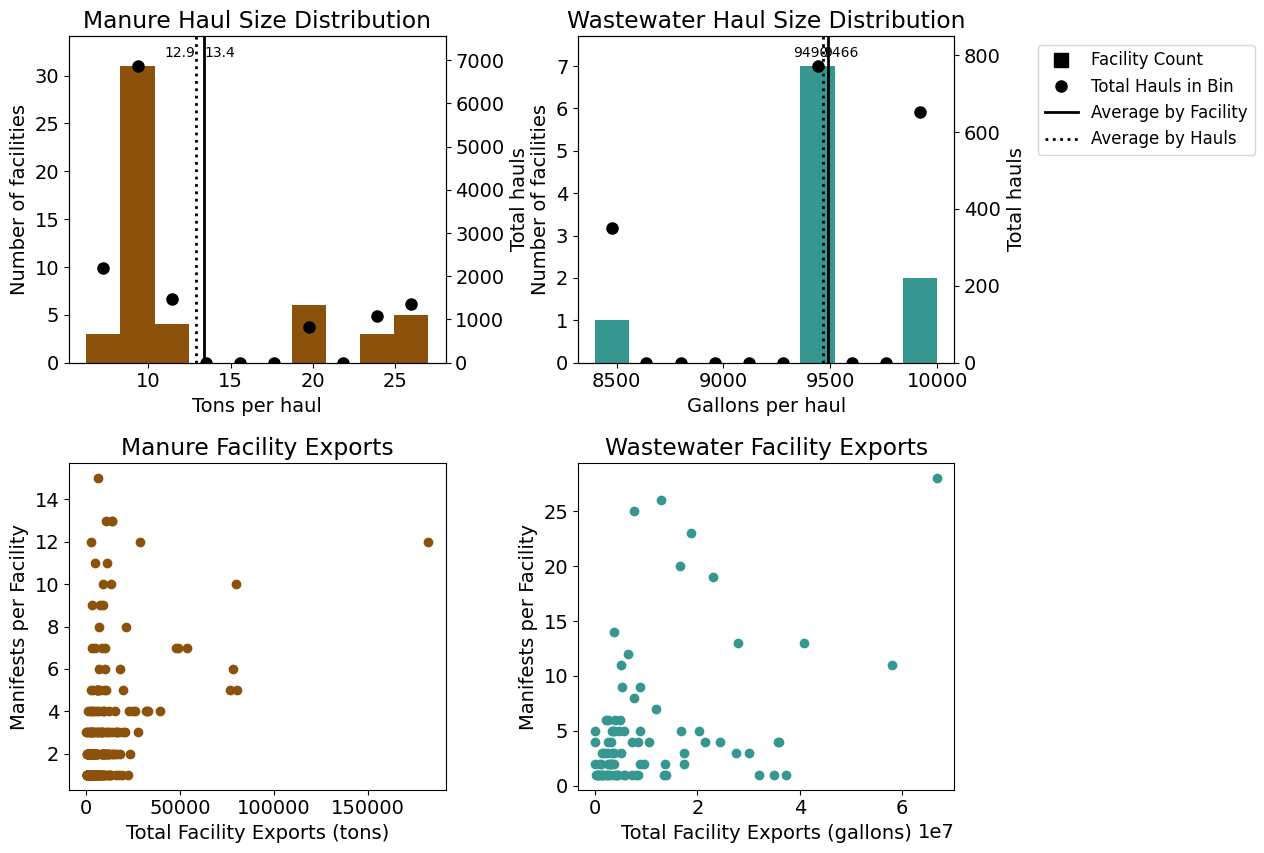

In [27]:
manual_clean = manual_src.copy()
coerce_columns(manual_clean)
dupe_mask = manual_clean.get("Is Duplicate", pd.Series()) == "x"
if dupe_mask.any():
    manual_clean = manual_clean[~dupe_mask].reset_index(drop=True)

# Add County from files_by_template where missing
if "County" not in manual_clean.columns:
    manual_clean["County"] = None
missing_county = manual_clean["County"].isna() | (manual_clean["County"] == "")
manual_clean.loc[missing_county, "County"] = manual_clean.loc[missing_county, "Source PDF"].map(county_map)

manual_clean = geocode_manifests(manual_clean)
manual_clean = backfill_columns(manual_clean)
df_manure_validated, df_ww_validated = process_and_save_manifests(manual_clean)

WATER_DENSITY = 8.34 / 2_000  # tons per gallon
ww_np = df_ww_validated[df_ww_validated[params["is_pipeline"]].ne(True)]  # non-pipeline only

type_configs = [
    ("Manure", df_manure_validated, params["manure_amount"], "tons"),
    ("Wastewater", df_ww_validated, params["wastewater_amount"], "gallons"),
]
haul_cfg = [
    ("Manure", df_manure_validated, params["manure_ton_per_haul"], params["manure_number_hauls"], 1.0),
    ("Wastewater", ww_np, params["wastewater_gallon_per_haul"], params["wastewater_number_hauls"], WATER_DENSITY),
]

def weighted_avg(df, val_col, weight_col):
    valid = df.dropna(subset=[val_col, weight_col])
    return (valid[val_col] * valid[weight_col]).sum() / valid[weight_col].sum()

def facility_agg(df, amount_col):
    tmp = df.copy()
    tmp["_manifest_norm"] = tmp["Manifest Number"].astype(str).str.replace(r"p\d+$", "", regex=True)
    per_manifest = tmp.groupby(["Source PDF", "_manifest_norm"])[amount_col].sum().reset_index()
    return (
        per_manifest.groupby("Source PDF")
        .agg(total_amount=(amount_col, "sum"), manifest_count=("_manifest_norm", "nunique"))
        .reset_index()
    )

def haul_bins(x_vals, totals, nbins=10):
    """Bin per-facility rates; return (centers, bin_totals, counts, edges)."""
    if len(x_vals) == 0:
        return [], [], np.array([0]), None
    counts, edges = np.histogram(x_vals, bins=nbins)
    centers = (edges[:-1] + edges[1:]) / 2
    cuts = pd.cut(x_vals, bins=edges, labels=False, include_lowest=True)
    bin_totals = [totals[cuts == i].sum() for i in range(len(edges) - 1)]
    return centers.tolist(), bin_totals, counts, edges

# Haul stats (rates converted to tons/haul via scale)
haul_stats = {}
for label, haul_df, rate_col, haul_col, scale in haul_cfg:
    fac = (
        haul_df.dropna(subset=[rate_col, haul_col])
        .groupby("Source PDF")
        .agg(avg_rate=(rate_col, "mean"), total_hauls=(haul_col, "sum"))
    )
    # For wastewater, do NOT convert to tons/haul; keep in gallons
    if label == "Wastewater":
        per_haul_series = fac["avg_rate"]  # gallons/haul
        avg_facility = fac["avg_rate"].mean()
        avg_weighted = weighted_avg(haul_df, rate_col, haul_col)
    else:
        per_haul_series = fac["avg_rate"] * scale
        avg_facility = (fac["avg_rate"] * scale).mean()
        avg_weighted = weighted_avg(haul_df, rate_col, haul_col) * scale
    haul_stats[label] = dict(
        facility_hauls=fac,
        per_haul_series=per_haul_series,
        avg_facility=avg_facility,
        avg_weighted=avg_weighted,
    )

manure_facility = facility_agg(df_manure_validated, params["manure_amount"])
ww_facility = facility_agg(df_ww_validated, params["wastewater_amount"])

# Hauls subplot
plt.rcParams["font.size"] = 14
fig_hauls, axes = plt.subplots(2, 2, figsize=(12, 8.75))
axes_twin = [axes[0, 0].twinx(), axes[0, 1].twinx()]
for ax, title in zip(axes.flat, [
    "Manure Haul Size Distribution", "Wastewater Haul Size Distribution",
    "Manure Facility Exports", "Wastewater Facility Exports",
]):
    ax.set_title(title)

plot_extras = [
    (COLORS["manure"], lambda v: round(v, 1), manure_facility, "tons"),
    (COLORS["wastewater"], int, ww_facility, "gallons"),
]
for col_idx, (label, *_) in enumerate(type_configs):
    hs = haul_stats[label]
    color, fmt, fac_df, unit = plot_extras[col_idx]
    bin_x, bin_totals, counts, edges = haul_bins(
        hs["per_haul_series"], hs["facility_hauls"]["total_hauls"]
    )
    ax_hist = axes[0, col_idx]
    ax_twin = axes_twin[col_idx]
    avg_fac, avg_w = hs["avg_facility"], hs["avg_weighted"]
    ann_ha = ("left", "right") if col_idx == 0 else ("right", "left")

    if edges is not None:
        ax_hist.hist(hs["per_haul_series"], bins=edges, color=color)
    ax_twin.scatter(bin_x, bin_totals, color="black", s=64, zorder=3)
    ax_hist.axvline(avg_fac, color="black", lw=2)
    ax_hist.axvline(avg_w, color="black", lw=2, ls="dotted")
    for avg, ha, text in [(avg_fac, ann_ha[0], fmt(avg_fac)), (avg_w, ann_ha[1], fmt(avg_w))]:
        ax_hist.annotate(str(text), xy=(avg, 0.97), xycoords=("data", "axes fraction"),
                         ha=ha, va="top", fontsize=10)
    ax_hist.set_xlabel(f"{unit.capitalize()} per haul")
    ax_hist.set_ylabel("Number of facilities")
    ax_twin.set_ylabel("Total hauls")
    if bin_totals:
        ax_twin.set_ylim(0, max(bin_totals) * 1.1)
    ax_hist.set_ylim(0, counts.max() * 1.1)

    axes[1, col_idx].scatter(fac_df["total_amount"], fac_df["manifest_count"], color=color)
    axes[1, col_idx].set_xlabel(f"Total Facility Exports ({unit})")
    axes[1, col_idx].set_ylabel("Manifests per Facility")

# Legend via phantom handles in top-right subplot
axes[0, 1].plot([], [], "s", color="black", ms=10, label="Facility Count")
axes[0, 1].plot([], [], "o", color="black", ms=8, label="Total Hauls in Bin")
axes[0, 1].plot([], [], "-", color="black", lw=2, label="Average by Facility")
axes[0, 1].plot([], [], ":", color="black", lw=2, label="Average by Hauls")
handles, labels = axes[0, 1].get_legend_handles_labels()
fig_hauls.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.2, 1),
                 bbox_transform=axes[0, 1].transAxes, fontsize=12)

fig_hauls.tight_layout()
fig_hauls.subplots_adjust(right=0.82)
fig_hauls.savefig(os.path.join("figures", "Supplementary_Figure_2.png"), dpi=200, bbox_inches="tight")



Validated vs automatic post-processed accuracy comparison

  Is Trucked: 839 manual, 705 auto, 100.00% accuracy
  Is Pipeline: 837 manual, 705 auto, 99.71% accuracy
  Total Manure Amount (tons): 837 manual, 705 auto, 96.82% accuracy
  Destination Nearest Cross Street: 237 manual, 233 auto, 96.14% accuracy
  Origin Dairy Address: 839 manual, 676 auto, 88.29% accuracy
  Total Process Wastewater Exports (Gallons): 422 manual, 419 auto, 87.44% accuracy
  Last Haul Date: 828 manual, 683 auto, 85.40% accuracy
  Hauler Name: 818 manual, 687 auto, 82.10% accuracy
  Manure Number of Hauls: 92 manual, 56 auto, 80.60% accuracy
  Origin Dairy Name: 833 manual, 686 auto, 78.72% accuracy
  Hauler Address: 803 manual, 673 auto, 72.78% accuracy
  Manure Mass per Haul (tons): 118 manual, 56 auto, 71.05% accuracy
  Destination Type (Standardized): 839 manual, 705 auto, 70.38% accuracy
  Destination Address: 642 manual, 555 auto, 69.45% accuracy
  Manure Solids (%): 695 manual, 450 auto, 65.39% accuracy
  First Haul Date: 261 manual, 184 auto, 61.95% accuracy
  

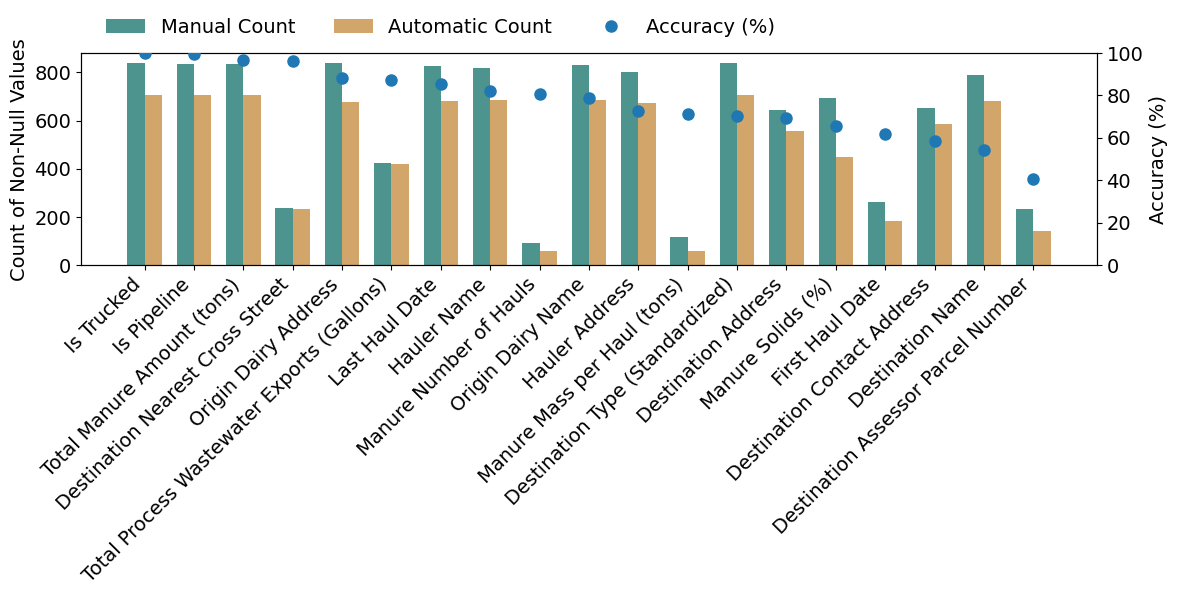

In [28]:
manure_processed_cols = df_manure_validated.columns.tolist()
ww_processed_cols = df_ww_validated.columns.tolist()

key_cols = {"Source PDF", "Manifest Number", "Start Page", "End Page"}
skip_cols = key_cols | {"Destination Address Final Source"} | {
    c for c in manure_processed_cols + ww_processed_cols if "(Geocoded)" in c
}
param_cols = set(PARAMETERS_DF["parameter_name"].tolist())

plt_values = []
seen_cols = set()
for col_list, manual_df_cmp, auto_df_cmp in [
    (manure_processed_cols, df_manure_validated, df_manure_auto),
    (ww_processed_cols, df_ww_validated, df_ww_auto),
]:
    for col in col_list:
        if col in skip_cols or col in seen_cols or "Hauls for Analysis" in col or "Method Used" in col or col == "Destination Type":
            continue
        if col not in param_cols:
            continue
        seen_cols.add(col)
        if col not in manual_df_cmp.columns or col not in auto_df_cmp.columns:
            continue
        manual_count = manual_df_cmp[col].notna().sum()
        auto_count = auto_df_cmp[col].notna().sum()
        merged_cmp = pd.merge(
            manual_df_cmp[["Source PDF", "Manifest Number", col]],
            auto_df_cmp[["Source PDF", "Manifest Number", col]],
            on=["Source PDF", "Manifest Number"],
            how="inner",
            suffixes=("_validated", "_auto"),
        )
        has_value = merged_cmp[f"{col}_validated"].notna() | merged_cmp[f"{col}_auto"].notna()
        comparable = merged_cmp[has_value]
        if len(comparable) == 0:
            plt_values.append((col, manual_count, auto_count, 0))
            continue
        m_col, e_col = f"{col}_validated", f"{col}_auto"
        if "address" in col.lower():
            matches = (
                comparable[m_col].apply(lambda x: norm_addr(x) if isinstance(x, str) else x)
                == comparable[e_col].apply(lambda x: norm_addr(x) if isinstance(x, str) else x)
            ).fillna(False)
        else:
            matches = (comparable[m_col] == comparable[e_col]).fillna(False)
        plt_values.append((col, manual_count, auto_count, matches.mean() * 100))

plt_values = [(col, mc, ac, acc) for col, mc, ac, acc in plt_values if mc >= 50 and ac >= 50]
plt_values.sort(key=lambda x: x[3], reverse=True)
indices = range(len(plt_values))
bar_width = 0.35
fig_acc, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
bars1 = ax1.bar(
    [i - bar_width / 2 for i in indices],
    [v[1] for v in plt_values],
    width=bar_width,
    label="Manual",
    alpha=0.7,
    color=COLORS["manual"],
)
bars2 = ax1.bar(
    [i + bar_width / 2 for i in indices],
    [v[2] for v in plt_values],
    width=bar_width,
    label="Automatic",
    alpha=0.7,
    color=COLORS["extracted"],
)
dots = ax2.plot(
    list(indices),
    [v[3] for v in plt_values],
    "o",
    color=COLORS["accuracy"],
    markersize=8,
    label="Accuracy (%)",
    zorder=5,
)
ax1.set_ylabel("Count of Non-Null Values")
ax2.set_ylabel("Accuracy (%)")
ax1.set_xticks(list(indices))
ax1.set_xticklabels([v[0] for v in plt_values], rotation=45, ha="right")
ax1.legend(
    [bars1, bars2, dots[0]],
    ["Manual Count", "Automatic Count", "Accuracy (%)"],
    bbox_to_anchor=(0.7, 1.25),
    ncol=3,
    frameon=False,
)
ax2.set_ylim(0, 100)
plt.tight_layout()
fig_acc.savefig(os.path.join("figures", "Supplementary_Figure_1.png"))
for col, manual_count, auto_count, accuracy in plt_values:
    print(f"  {col}: {manual_count} manual, {auto_count} auto, {accuracy:.2f}% accuracy")